<a href="https://colab.research.google.com/github/volobueva-ve/projects/blob/main/pricerise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Загружаем необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns



Подключаемся к kaggle

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Загружаем необходимые нам данные, и распаковываем их

In [ ]:
!kaggle datasets download akshaymairal/store-item-demand-forecasting-challenge

Dataset URL: https://www.kaggle.com/datasets/akshaymairal/store-item-demand-forecasting-challenge
License(s): MIT
100% 3.29M/3.29M [00:00<00:00, 174MB/s]



In [ ]:
!unzip store-item-demand-forecasting-challenge.zip -d forecast

Archive:  store-item-demand-forecasting-challenge.zip
  inflating: forecast/sample_submission.csv  
  inflating: forecast/test.csv       
  inflating: forecast/train.csv      


#EDA(исследовательский анализ данных)

In [ ]:
import pandas as pd
df_test=pd.read_csv('forecast/test.csv')
print("Размер датасета для предсказания:", df_test.shape)
print(df_test.head())
df_train = pd.read_csv('forecast/train.csv')
print("Размер тренировочного датасета:", df_train.shape)
print(df_train.head())
print('Колонки в train:', df_train.columns.tolist())

Размер датасета для предсказания: (45000, 4)
   id        date  store  item
0   0  2018-01-01      1     1
1   1  2018-01-02      1     1
2   2  2018-01-03      1     1
3   3  2018-01-04      1     1
4   4  2018-01-05      1     1
Размер тренировочного датасета: (913000, 4)
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
Колонки в train: ['date', 'store', 'item', 'sales']


Информация о тренировочном датасете

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


Анализ пропущенных значений

In [ ]:
print("Количество пропущенных значений для test.csv")
for col in df_test.columns:
  pct_missing = np.mean(df_test[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))
print("Количество пропущенных значений для train.csv")
for col in df_train.columns:
  pct_missing = np.mean(df_train[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))


Количество пропущенных значений для test.csv
id - 0%
date - 0%
store - 0%
item - 0%
Количество пропущенных значений для train.csv
date - 0%
store - 0%
item - 0%
sales - 0%


Анализ дублирующихся записей

In [ ]:
duplicate_count = df_train.duplicated().sum()

print("Количество повторяющихся строк:", duplicate_count)

Количество повторяющихся строк: 0


Анализ целевой переменной

In [ ]:
df_train['sales'].describe()

,sales
count,913000.000000
mean,52.250287
std,28.801144
min,0.000000
25%,30.000000
50%,47.000000
75%,70.000000
max,231.000000


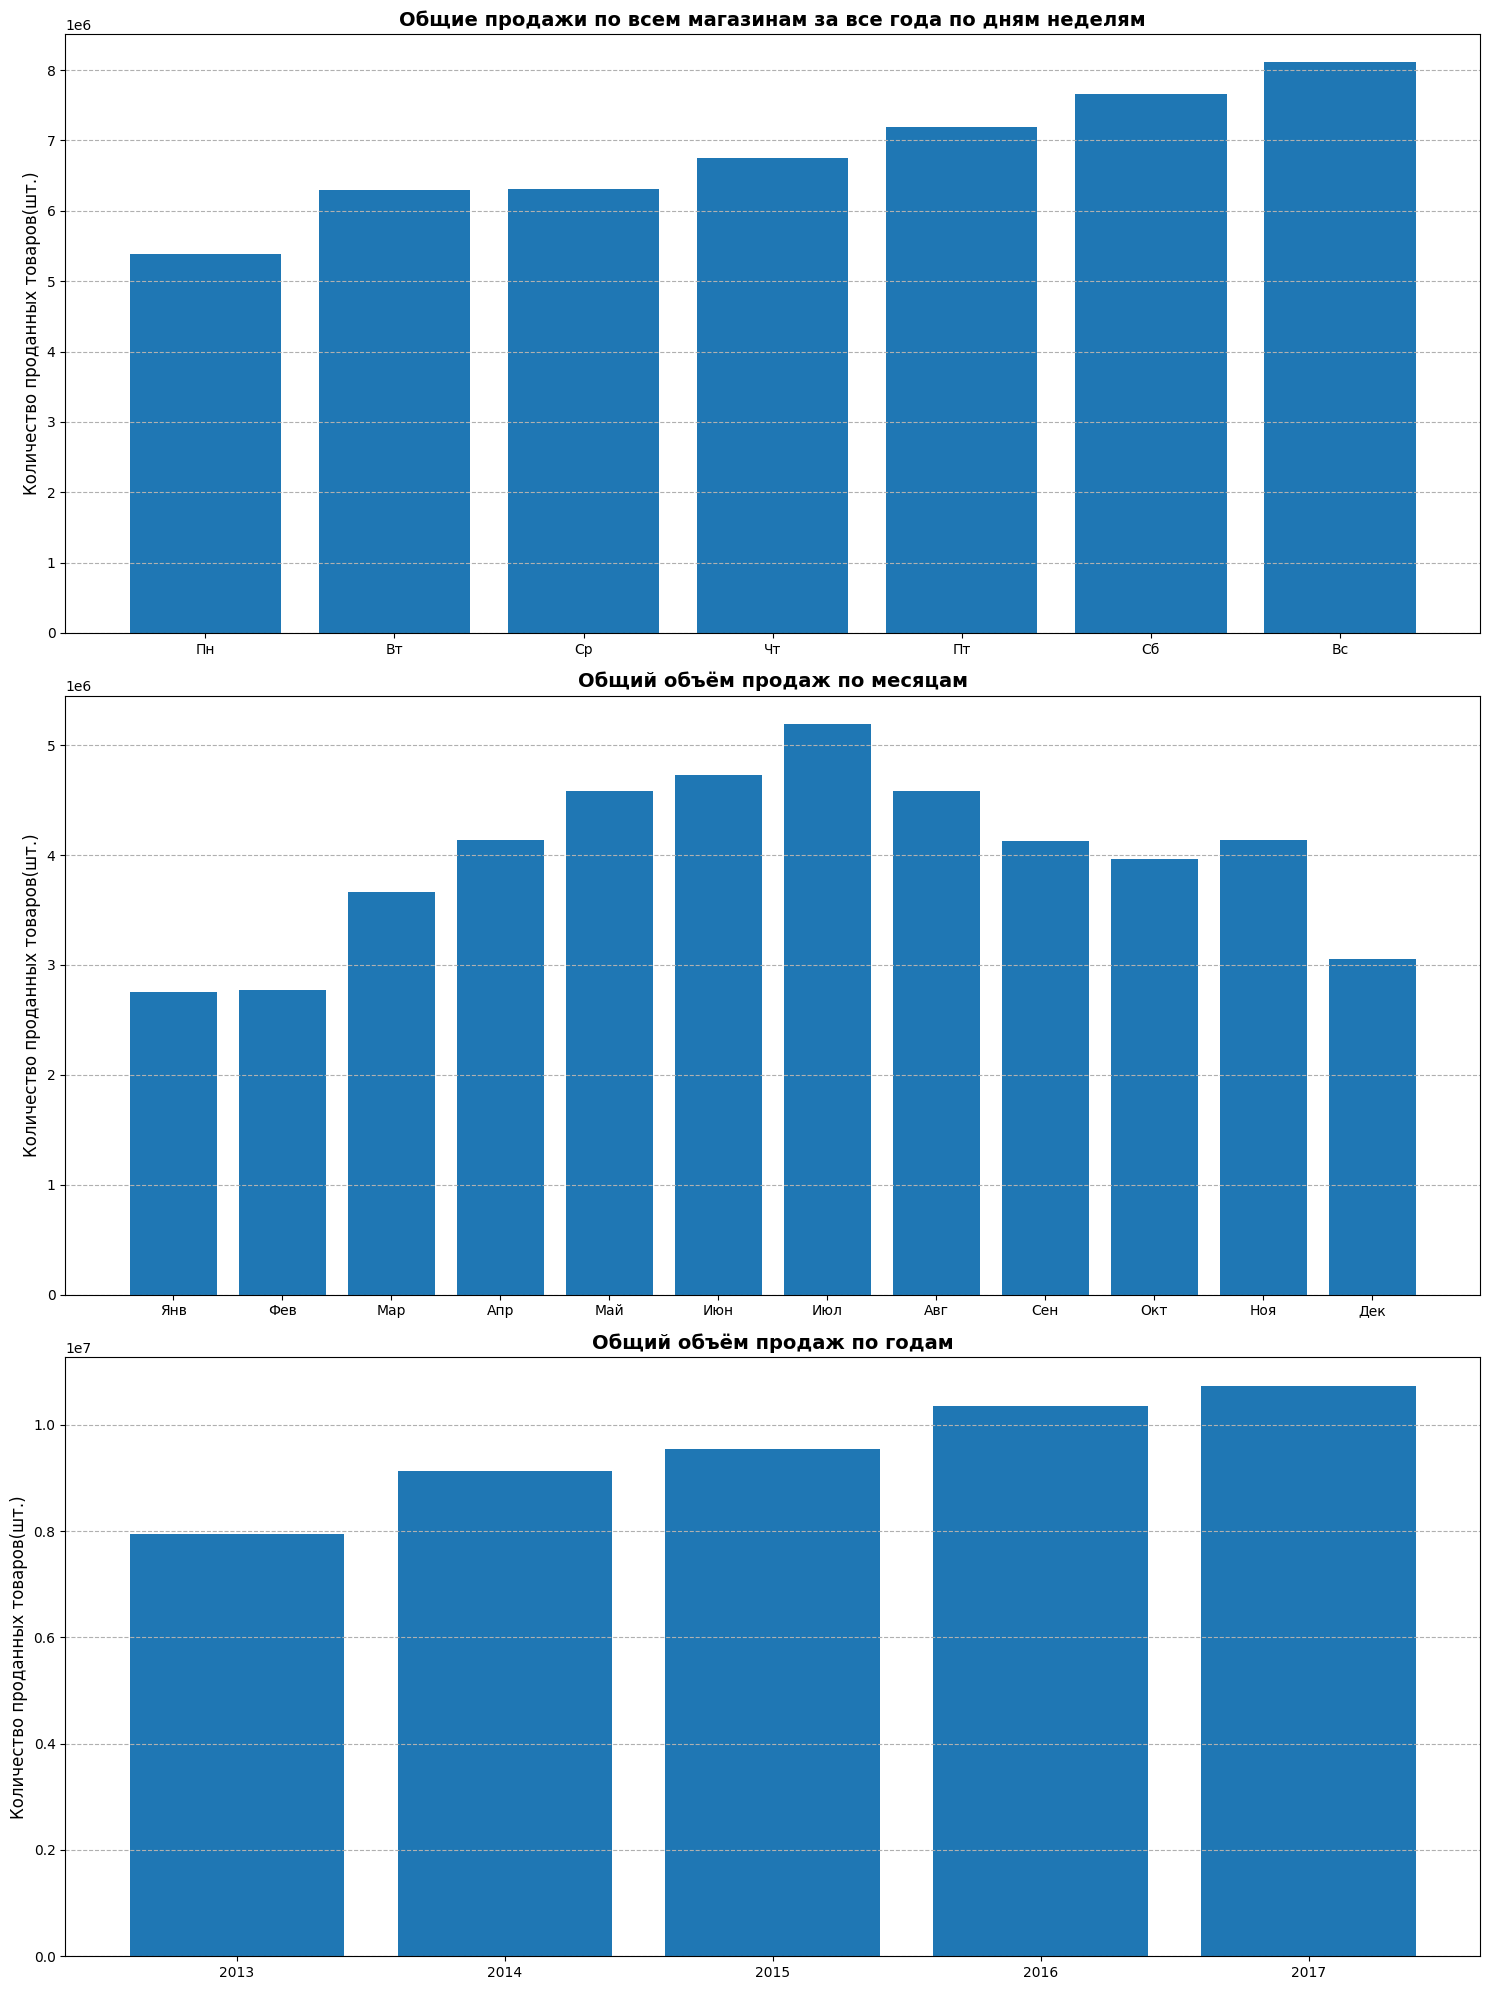

In [ ]:
# Извлекаем компоненты даты в новые колонки
df_train['date']= pd.to_datetime(df_train['date'])
df_train['day_of_week'] = df_train['date'].dt.dayofweek # 0 - Понедельник, 6 - Воскресенье
df_train['month'] = df_train['date'].dt.month           # 1 - Январь, 12 - Декабрь
df_train['year'] = df_train['date'].dt.year

#Суммируем продажи по всем магазинам и товарам
sales_by_dow = df_train.groupby('day_of_week')['sales'].sum()
sales_by_month = df_train.groupby('month')['sales'].sum()
sales_by_year = df_train.groupby('year')['sales'].sum()

#Визуализация
dow_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
month_labels = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
fig, axes = plt.subplots(3, 1, figsize=(15, 20))
#График 1: Тренд по днм неделям
axes[0].bar(dow_labels, sales_by_dow.values)
axes[0].set_title('Общие продажи по всем магазинам за все года по дням неделям', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество проданных товаров(шт.)', fontsize=12)
axes[0].grid(axis='y', linestyle='--')
#График 2: Сезонность по месяцам
axes[1].bar(month_labels, sales_by_month.values)
axes[1].set_title('Общий объём продаж по месяцам', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Количество проданных товаров(шт.)', fontsize=12)
axes[1].grid(axis='y', linestyle='--')
#График 3: Глобальный тренд по годам
axes[2].bar(sales_by_year.index, sales_by_year.values)
axes[2].set_title('Общий объём продаж по годам', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Количество проданных товаров(шт.)', fontsize=12)
axes[2].grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

1) Объём продаж растёт с пн по вс, в выходные дни самые выоские продажи
2) Наиболее большой объём продаж в течение года наблюдается в июле
3) С каждым годом объём продаж за год растёт

Анализ временных рядов

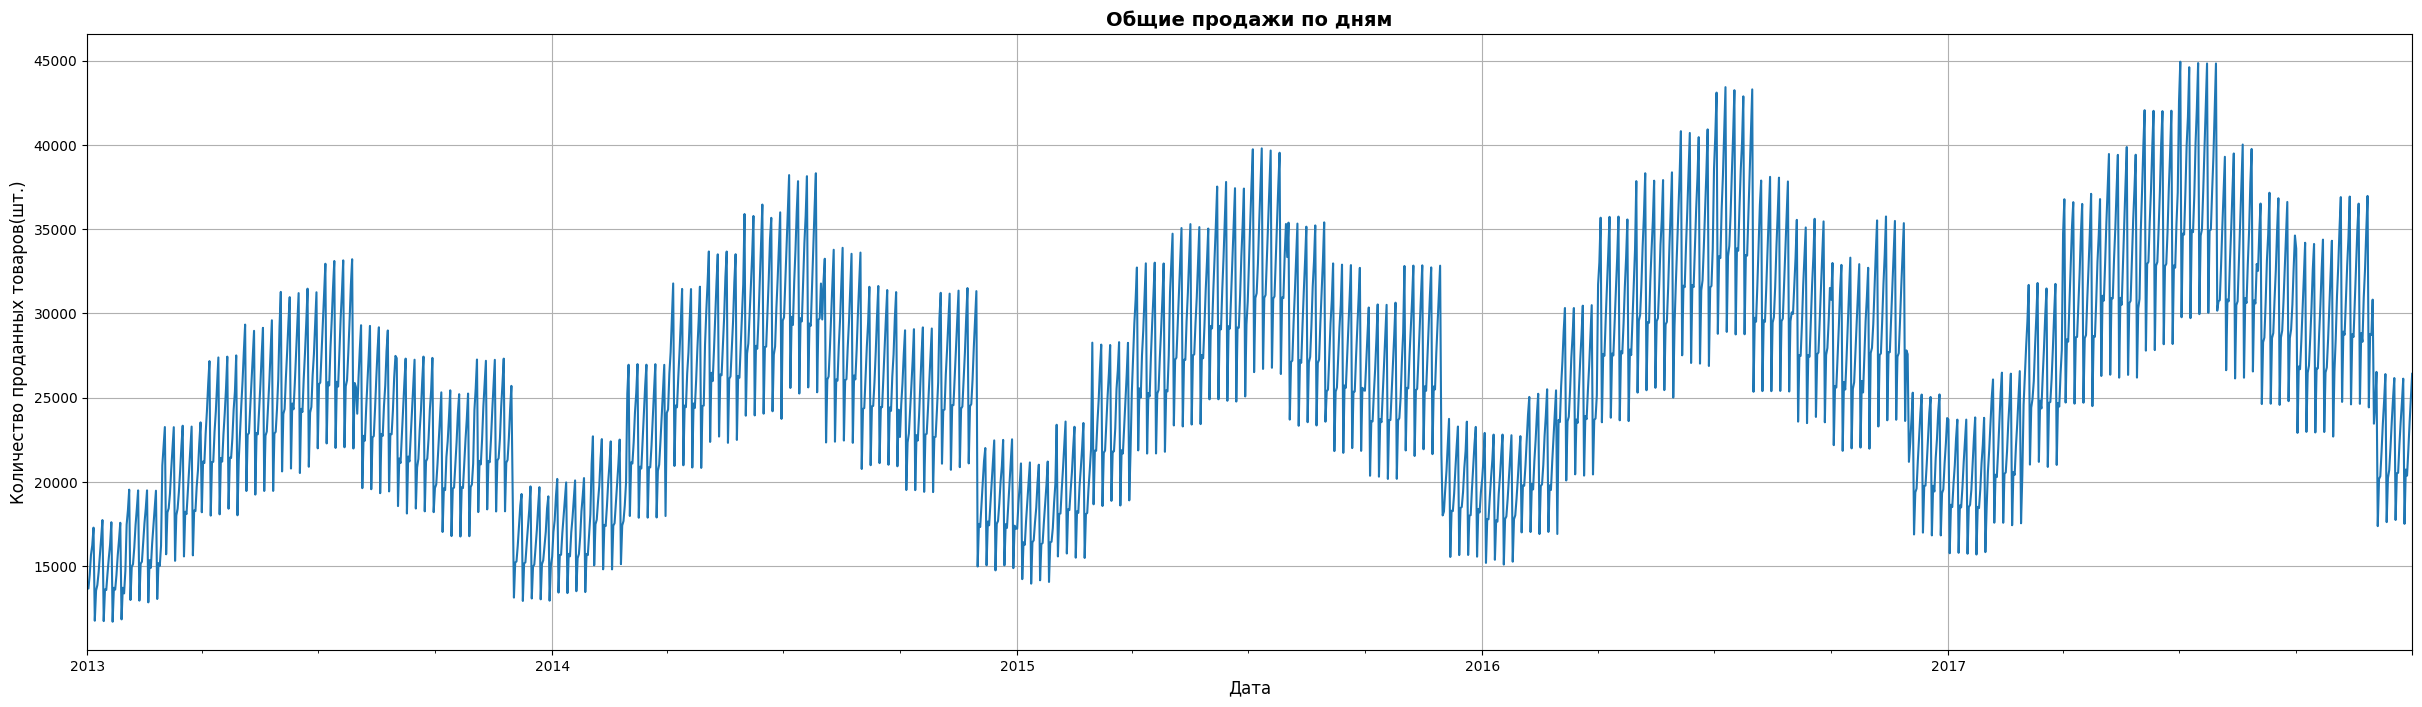

In [ ]:
plt.figure(figsize=(30, 8))
#График общего объёма продаж за все дни
daily_sales = df_train.groupby("date")["sales"].sum()
daily_sales.plot()
plt.title('Общие продажи по дням', fontsize=14,  fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество проданных товаров(шт.)', fontsize=12)
plt.grid()
plt.show()

1) Общие продажи демонстрируют явный восходящий тренд с течением времени
2) Спрос постепенно растет с 2013 по 2017 год
3) Похожие колебания продаж повторяются каждый год
4) Часто повторяющиеся пики указывают на то, что продажи сильно завяисят от дня недели

Распределение продаж

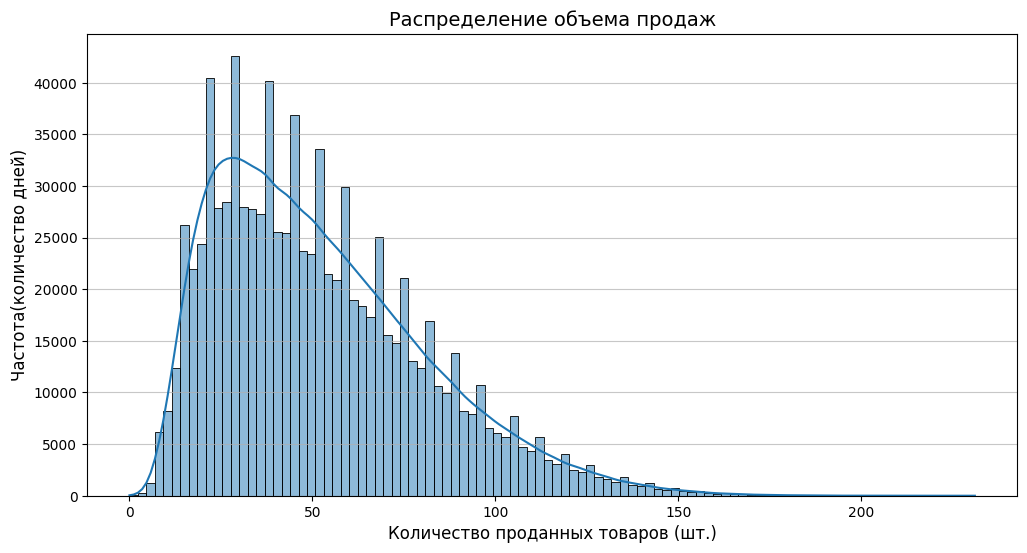

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_train['sales'], bins=100, kde=True)
plt.title('Распределение объема продаж', fontsize=14)
plt.xlabel('Количество проданных товаров (шт.)', fontsize=12)
plt.ylabel('Частота(количество дней)', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.show()

1) Большинство наблюдений сосредоточено между 20 и 80 единицами
2) Распределение объёма продаж не подчиняется нормальному распределению
3) Имеется длинная хвостовая часть, что указывает на наличие наблюдений с высокими продажами

#Создание обучающей выборки

In [ ]:
#Сортируем данные
df_train = df_train.sort_values(['store', 'item', 'date'])
#Добавляем признаки для обучающей выборки
df_train['lag_1'] = df_train.groupby(['store', 'item'])['sales'].shift(1)
df_train['lag_7'] = df_train.groupby(['store', 'item'])['sales'].shift(7)
df_train['lag_14'] = df_train.groupby(['store', 'item'])['sales'].shift(14)
df_train['lag_30'] = df_train.groupby(['store', 'item'])['sales'].shift(30)
df_train['roll_mean_7'] = (df_train.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).rolling(7).mean())
df_train['roll_mean_28'] = (df_train.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).rolling(28).mean())
df_train['ewm_0.5'] = (df_train.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).ewm(alpha=0.5).mean())
df_train['ewm_0.1'] = (df_train.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).ewm(alpha=0.1).mean())
df_train.head(120)

,date,store,item,sales,day_of_week,month,year,lag_1,lag_7,lag_14,lag_30,roll_mean_7,roll_mean_28,ewm_0.5,ewm_0.1
0,2013-01-01,1,1,13,1,1,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,1,2013,13.0,NaN,NaN,NaN,NaN,NaN,13.000000,13.000000
2,2013-01-03,1,1,14,3,1,2013,11.0,NaN,NaN,NaN,NaN,NaN,11.666667,11.947368
3,2013-01-04,1,1,13,4,1,2013,14.0,NaN,NaN,NaN,NaN,NaN,13.000000,12.704797
4,2013-01-05,1,1,10,5,1,2013,13.0,NaN,NaN,NaN,NaN,NaN,13.000000,12.790637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2013-04-26,1,1,20,4,4,2013,14.0,22.0,18.0,11.0,16.428571,17.535714,13.719528,16.467343
116,2013-04-27,1,1,22,5,4,2013,20.0,22.0,17.0,13.0,16.142857,17.642857,16.859764,16.820611
117,2013-04-28,1,1,19,6,4,2013,22.0,20.0,26.0,17.0,16.142857,17.750000,19.429882,17.338552
118,2013-04-29,1,1,11,0,4,2013,19.0,13.0,14.0,19.0,16.000000,17.714286,19.214941,17.504697


In [ ]:
#Удаляем пропущенные значения
df_train.dropna(inplace=True)
df_train.reset_index(drop=True, inplace=True)

#Оптимизация гиперпараметров модели

In [ ]:
#Загружаем библиотеку optuna
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.1 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import optuna

In [ ]:
import warnings
warnings.filterwarnings('ignore')
#Вводим метрику качества модели
def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.abs(np.array(y_pred, dtype=float))
    denom  = np.abs(y_true) + y_pred
    return 100.0 * np.mean(2 * np.abs(y_pred - y_true) / np.where(denom==0, 1e-8, denom))

# Инициализируем кросс-валидацию для временных рядов (обучение строго на прошлом без утечек в будущее)
tss= TimeSeriesSplit()
#Отделяем матрицу признаков от целевой переменной
features = df_train.iloc[:,7:]
target = df_train['sales']
print(features.head(10))

# Функция для Optuna, которая будет искать лучшие гиперпараметры
def objective(trial):
  params = {'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0)}
  lgb1 = lgb.LGBMRegressor(**params, verbose = -1)
  smape_scores = []
  for train_index, test_index in tss.split(features, target):
    features_train, features_test = features.iloc[train_index], features.iloc[test_index]
    target_train, target_test = target[train_index], target[test_index]
    lgb1.fit(features_train, target_train)
    y_pred = lgb1.predict(features_test)
    smape_scores.append(smape(target_test, y_pred))
  return np.mean(smape_scores)
#Запускаем оптимизацию
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
print('Лучший smape:', study.best_value)
print('Лучшие гиперпараметры:',study.best_params)
#Сохраняем лучшие гиперпараметры
params = study.best_params
params['random_state'] = 42
#Выводим результат подбора парметров: смотрим какие значения мы предсказываем и
#какие являются актуальными для этой даты
best_model = lgb.LGBMRegressor(**params)
splits = list(tss.split(features,target))
train_index, test_index = splits[-1]
features_train, features_test = features.iloc[train_index], features.iloc[test_index]
target_train, target_test = target[train_index], target[test_index]
best_model.fit(features_train, target_train)
y_pred = best_model.predict(features_test)
print(pd.DataFrame({'Actual': target_test, 'Predicted': y_pred}))

[I 2026-06-25 11:27:20,942] A new study created in memory with name: no-name-bcb8ca6a-713d-42f2-b6d1-19a34c23cea5


   lag_1  lag_7  lag_14  lag_30  roll_mean_7  roll_mean_28    ewm_0.5  \
0    9.0    8.0    16.0    13.0    10.285714     10.392857   8.851891   
1   13.0   14.0     7.0    11.0    11.000000     10.357143  10.925946   
2   11.0   12.0    18.0    14.0    10.571429     10.285714  10.962973   
3   21.0   12.0    15.0    13.0    11.857143     10.678571  15.981486   
4   15.0   11.0     8.0    10.0    12.285714     10.785714  15.490743   
5   14.0    6.0     7.0    12.0    12.714286     10.928571  14.745372   
6    9.0    9.0     9.0    10.0    13.142857     10.928571  11.872686   
7   10.0   13.0     8.0     9.0    13.285714     10.857143  10.936343   
8   13.0   11.0    14.0    12.0    13.285714     11.000000  11.968171   
9   11.0   21.0    12.0     9.0    13.285714     11.071429  11.484086   

     ewm_0.1  
0  10.158134  
1  10.453593  
2  10.510177  
3  11.592610  
4  11.943097  
5  12.154068  
6  11.831392  
7  11.644463  
8  11.782536  
9  11.702976  


[I 2026-06-25 11:28:32,850] Trial 0 finished with value: 14.652640115595142 and parameters: {'n_estimators': 348, 'learning_rate': 0.050067114170224275, 'num_leaves': 81, 'max_depth': 8, 'feature_fraction': 0.7871370658768727}. Best is trial 0 with value: 14.652640115595142.
[I 2026-06-25 11:30:16,460] Trial 1 finished with value: 14.64221309735222 and parameters: {'n_estimators': 436, 'learning_rate': 0.027097716283300613, 'num_leaves': 82, 'max_depth': 12, 'feature_fraction': 0.9949897058589837}. Best is trial 1 with value: 14.64221309735222.
[I 2026-06-25 11:31:22,726] Trial 2 finished with value: 14.772518701900964 and parameters: {'n_estimators': 423, 'learning_rate': 0.024171698379862674, 'num_leaves': 32, 'max_depth': 6, 'feature_fraction': 0.6461551028773113}. Best is trial 1 with value: 14.64221309735222.
[I 2026-06-25 11:31:47,563] Trial 3 finished with value: 14.738467948699412 and parameters: {'n_estimators': 135, 'learning_rate': 0.09072530757457985, 'num_leaves': 35, 'max

Лучший smape: 14.619120410988842
Лучшие гиперпараметры: {'n_estimators': 392, 'learning_rate': 0.06729016048870816, 'num_leaves': 89, 'max_depth': 12, 'feature_fraction': 0.7006370180959187}
        Actual  Predicted
748334      45  47.356848
748335      43  44.909800
748336      47  50.192323
748337      29  33.483260
748338      40  39.807474
...        ...        ...
897995      63  57.311110
897996      59  65.973256
897997      74  68.293909
897998      62  63.245629
897999      82  74.974748

[149666 rows x 2 columns]


#Обучение и предсказание модели

In [ ]:
#Сохраняем колонки признаков
feature_cols = features.columns.tolist()
#Инициализируем модель для обучения с лучшими гиперпараметрами
final_model = lgb.LGBMRegressor(**params)
#Тренируем модель
final_model.fit(features, target)
#Создаём общую таблицу для тренировочной и тестовой таблиц
df_all= pd.concat([df_train, df_test])
#Приводим даты к нужному формату
df_all['date'] = pd.to_datetime(df_all['date'])
#Сортируем данные
df_all = df_all.sort_values(['store', 'item', 'date'])

dates_to_predict = pd.date_range(start='2018-01-01', end='2018-03-31')

df_test['sales'] = []
#Запускаем рекурсивный цикл
for curr_date in dates_to_predict:
  #Пересчёт признаков
  df_all['lag_1'] = df_all.groupby(['store', 'item'])['sales'].shift(1)
  df_all['lag_7'] = df_all.groupby(['store', 'item'])['sales'].shift(7)
  df_all['lag_14'] = df_all.groupby(['store', 'item'])['sales'].shift(14)
  df_all['lag_30'] = df_all.groupby(['store', 'item'])['sales'].shift(30)
  df_all['roll_mean_7'] = (df_all.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).rolling(7).mean())
  df_all['roll_mean_28'] = (df_all.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).rolling(28).mean())
  df_all['ewm_0.5'] = (df_all.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).ewm(alpha=0.5).mean())
  df_all['ewm_0.1'] = (df_all.groupby(['store', 'item'])['sales']).transform(lambda x: x.shift(1).ewm(alpha=0.1).mean())
  #Создаём маску текущего дня
  today_mask = df_all['date'] == curr_date
  today_data = df_all.loc[today_mask, feature_cols]
  #Предказываем и записываем
  predicted = final_model.predict(today_data)
  df_test.loc[today_mask, 'sales'] = predicted
  df_all.loc[today_mask, 'sales'] = predicted
print('Таблица с предсказанными значениями продаж')
print(df_test)


ValueError: Length of values (0) does not match length of index (45000)

In [ ]:
df_predict = df_all.loc['date','store','item','sales'].tail(90)